In [13]:
# Data handling and numerical computations
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning packages
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from imblearn.over_sampling import SMOTE

# Machine learning models (Basic)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Machine learning models (Advanced)
from xgboost import XGBClassifier
#from lightgbm import LGBMClassifier
from sklearn.neural_network import MLPClassifier

# Model evaluation
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, precision_recall_curve

# Real-time data and deployment (for future use)
import joblib
import datetime

# Ignoring warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
sns.set(style='whitegrid')

print("Initial packages imported successfully.")


Initial packages imported successfully.


In [14]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Load datasets
station_data = pd.read_csv(
    "/Users/tranhuytuan/Documents/quang lam cl j/trafficStations (1).csv",
)

traffic_data = pd.read_csv(
    "/Users/tranhuytuan/Documents/quang lam cl j/trafficData.csv"
)

weather_data = pd.read_csv(
    "/Users/tranhuytuan/Documents/quang lam cl j/weatherData.csv"
)

print("🧾 Unique values in raw lane_count:")
print(station_data['lane_count'].unique())




🧾 Unique values in raw lane_count:
['OneLane' 'TwoOrMoreLanes' 'Unknown Lanes']


In [15]:
# === Convert lane_count from text to numerical values ===
station_data['lane_count'] = station_data['lane_count'].replace({
    'OneLane': 1,
    'TwoOrMoreLanes': 2,
    'Unknown Lanes': 1  # <- fixed typo here
}).astype("float")

# === Select only relevant station columns ===
station_cols = [
    'station_key', 'road_functional_hierarchy', 'lane_count',
    'road_classification_type', 'suburb', 'wgs84_latitude', 'wgs84_longitude'
]
station_data = station_data[station_cols]

# === Merge station metadata into traffic data ===
data_A = traffic_data.merge(station_data, on="station_key", how="left")

# === Construct date column and lat/lon rounding ===
data_A['date'] = pd.to_datetime(data_A[['year','month','day']])
data_A['lat_rounded'] = data_A['wgs84_latitude'].round(3)
data_A['lon_rounded'] = data_A['wgs84_longitude'].round(3)
weather_data['date'] = pd.to_datetime(weather_data['date'])

# === 🧹 Filter weather_data to only relevant locations/dates ===
unique_locations = data_A[['lat_rounded', 'lon_rounded']].drop_duplicates()
unique_dates = data_A['date'].drop_duplicates()

weather_filtered = weather_data.merge(unique_locations, on=['lat_rounded', 'lon_rounded'], how='inner')
weather_filtered = weather_filtered[weather_filtered['date'].isin(unique_dates)]

# === Merge weather data into traffic+station data ===
df = data_A.merge(
    weather_filtered,
    on=['lat_rounded', 'lon_rounded', 'date'],
    how='left'
)

# === Sanity Check ===
print("✅ Final columns in df:")
print(df.columns.tolist())
print(f"\n🧪 lane_count nulls: {df['lane_count'].isna().sum()}")
print("🧪 Sample lane_count values:\n", df['lane_count'].value_counts(dropna=False))


✅ Final columns in df:
['station_key', 'traffic_direction_seq', 'cardinal_direction_seq', 'classification_seq', 'year', 'month', 'day', 'day_of_week', 'public_holiday', 'school_holiday', 'daily_total', 'hour_00', 'hour_01', 'hour_02', 'hour_03', 'hour_04', 'hour_05', 'hour_06', 'hour_07', 'hour_08', 'hour_09', 'hour_10', 'hour_11', 'hour_12', 'hour_13', 'hour_14', 'hour_15', 'hour_16', 'hour_17', 'hour_18', 'hour_19', 'hour_20', 'hour_21', 'hour_22', 'hour_23', 'road_functional_hierarchy', 'lane_count', 'road_classification_type', 'suburb', 'wgs84_latitude', 'wgs84_longitude', 'date', 'lat_rounded', 'lon_rounded', 'daily_rain', 'max_temp', 'min_temp']

🧪 lane_count nulls: 0
🧪 Sample lane_count values:
 lane_count
2.0    3397752
1.0      67670
Name: count, dtype: int64


In [16]:
# ─── Code Cell 2: Compute Densities + Daily Density + Labeling ───────────────

# Function to safely compute density per lane
def safe_density(count, lanes):
    lanes = lanes.replace(0, pd.NA)
    return count / lanes

# Define time windows
time_windows = {
    'night':     list(range(22, 24)) + list(range(0, 4)),
    'morning':   list(range(4, 10)),
    'afternoon': list(range(10, 16)),
    'evening':   list(range(16, 22)),
}

# Compute densities per window (using hourly counts)
for name, hours in time_windows.items():
    hour_cols = [f'hour_{h:02d}' for h in hours if f'hour_{h:02d}' in df.columns]
    df[f'{name}_count'] = df[hour_cols].sum(axis=1)
    df[f'{name}_density'] = safe_density(df[f'{name}_count'], df['lane_count'])

# Compute daily_density (total daily vehicles per lane)
df['daily_density'] = safe_density(df['daily_total'], df['lane_count'])

# Categorize densities into 4 traffic states
def categorize_density(density):
    if pd.isna(density):
        return pd.NA
    elif density <= 100:
        return 0  # low
    elif density <= 1000:
        return 1  # medium
    elif density <= 10000:
        return 2  # high
    else:
        return 3  # congested

# Create label columns for each time window
for name in time_windows:
    df[f'{name}_label'] = df[f'{name}_density'].apply(categorize_density)

# Optional: create a daily_label for overall daily density
df['daily_label'] = df['daily_density'].apply(categorize_density)

# Sanity check
print("✅ Created density and label columns:")
print([col for col in df.columns if col.endswith('_density') or col.endswith('_label')])
print("\n📊 Label distribution examples:")
for name in list(time_windows.keys()) + ['daily']:
    print(f"\n{name.title()} label counts:")
    print(df[f'{name}_label'].value_counts(dropna=False))

✅ Created density and label columns:
['night_density', 'morning_density', 'afternoon_density', 'evening_density', 'daily_density', 'night_label', 'morning_label', 'afternoon_label', 'evening_label', 'daily_label']

📊 Label distribution examples:

Night label counts:
night_label
1    1553871
0    1553773
2     357719
3         59
Name: count, dtype: int64

Morning label counts:
morning_label
2    1519635
1    1231286
0     702938
3      11563
Name: count, dtype: int64

Afternoon label counts:
afternoon_label
2    1832122
1    1161355
0     437796
3      34149
Name: count, dtype: int64

Evening label counts:
evening_label
2    1665689
1    1010774
0     767110
3      21849
Name: count, dtype: int64

Daily label counts:
daily_label
2    1424147
1    1051547
3     828377
0     161351
Name: count, dtype: int64


In [17]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import cycle
import numpy as np

cat_cols = ['traffic_direction_seq', 'road_classification_type', 'road_functional_hierarchy', 'suburb']

# One-hot encode categoricals if not done yet
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True, dtype=int)

feature_cols = [
    'year', 'month', 'day', 'day_of_week',
    'public_holiday', 'school_holiday',
    'lane_count', 'daily_density',  # add daily_density as feature
    'daily_rain', 'max_temp', 'min_temp'
] + [col for col in df_encoded.columns if col.startswith(tuple(cat_cols))]

print(df.columns.tolist())

# 1) Inspect all column dtypes
print("🔍 Column types in df_encoded:")
print(df_encoded.dtypes.value_counts())
print(df_encoded.dtypes)  # full listing

# 2) Find non-numeric columns
non_numeric = df_encoded.select_dtypes(include=['object','bool']).columns.tolist()
print(f"\n⚠️ Non-numeric columns ({len(non_numeric)}): {non_numeric}")

['station_key', 'traffic_direction_seq', 'cardinal_direction_seq', 'classification_seq', 'year', 'month', 'day', 'day_of_week', 'public_holiday', 'school_holiday', 'daily_total', 'hour_00', 'hour_01', 'hour_02', 'hour_03', 'hour_04', 'hour_05', 'hour_06', 'hour_07', 'hour_08', 'hour_09', 'hour_10', 'hour_11', 'hour_12', 'hour_13', 'hour_14', 'hour_15', 'hour_16', 'hour_17', 'hour_18', 'hour_19', 'hour_20', 'hour_21', 'hour_22', 'hour_23', 'road_functional_hierarchy', 'lane_count', 'road_classification_type', 'suburb', 'wgs84_latitude', 'wgs84_longitude', 'date', 'lat_rounded', 'lon_rounded', 'daily_rain', 'max_temp', 'min_temp', 'night_count', 'night_density', 'morning_count', 'morning_density', 'afternoon_count', 'afternoon_density', 'evening_count', 'evening_density', 'daily_density', 'night_label', 'morning_label', 'afternoon_label', 'evening_label', 'daily_label']
🔍 Column types in df_encoded:
int64             414
float64            13
bool                2
datetime64[ns]      1
N


⏱️ Training model for: NIGHT
              precision    recall  f1-score   support

         low      0.962     0.965     0.963    310755
      medium      0.931     0.944     0.937    310774
        high      0.916     0.846     0.879     71544
   congested      1.000     0.667     0.800        12

    accuracy                          0.943    693085
   macro avg      0.952     0.855     0.895    693085
weighted avg      0.943     0.943     0.943    693085



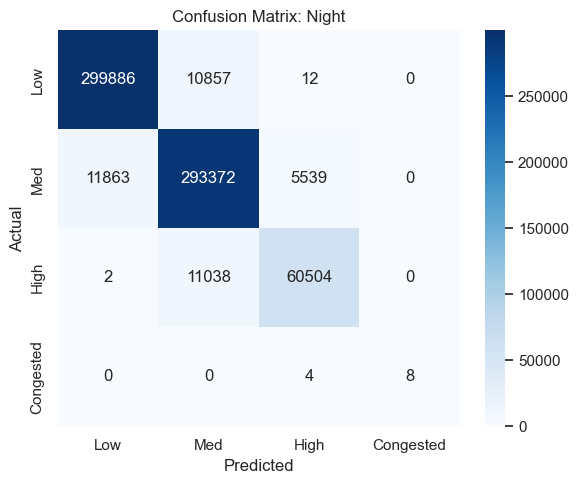

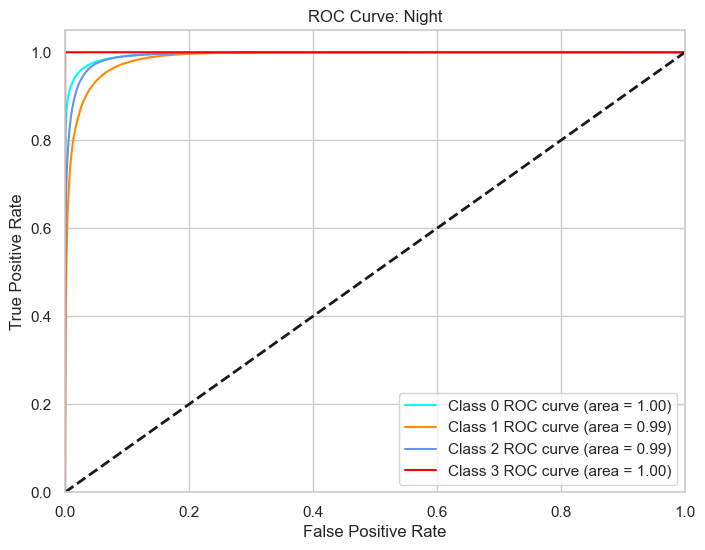


⏱️ Training model for: MORNING
              precision    recall  f1-score   support

         low      0.964     0.950     0.957    140588
      medium      0.952     0.950     0.951    246257
        high      0.974     0.983     0.979    303927
   congested      0.953     0.917     0.935      2313

    accuracy                          0.964    693085
   macro avg      0.961     0.950     0.955    693085
weighted avg      0.964     0.964     0.964    693085



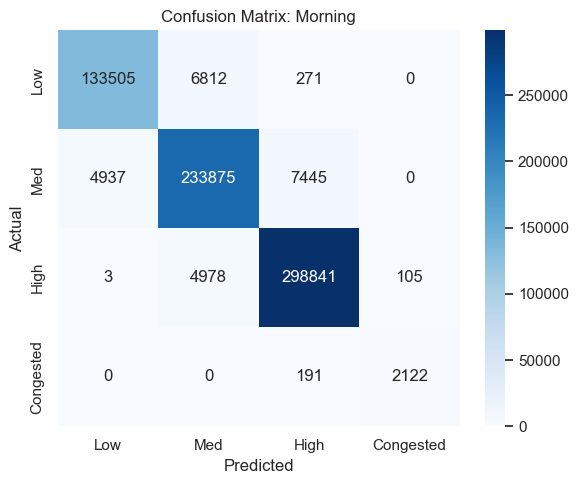

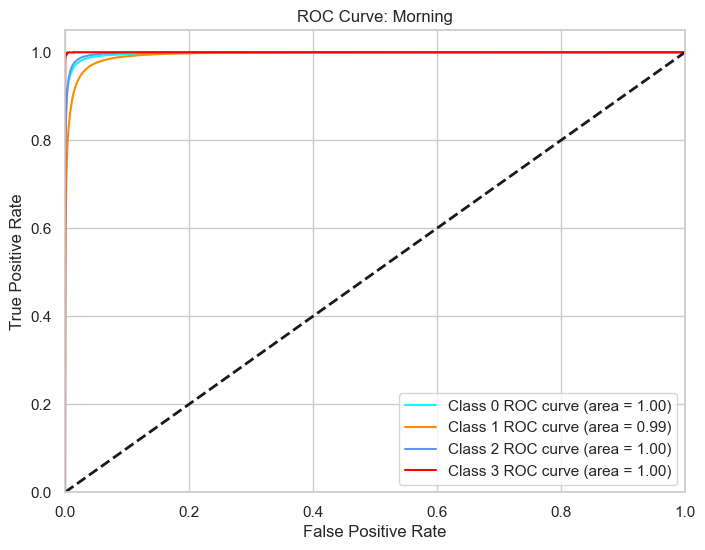


⏱️ Training model for: AFTERNOON
              precision    recall  f1-score   support

         low      0.954     0.945     0.950     87559
      medium      0.970     0.972     0.971    232271
        high      0.992     0.993     0.992    366425
   congested      0.953     0.955     0.954      6830

    accuracy                          0.979    693085
   macro avg      0.967     0.966     0.967    693085
weighted avg      0.979     0.979     0.979    693085



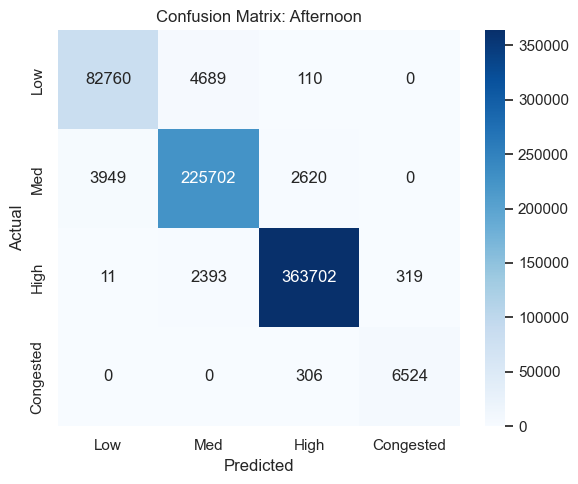

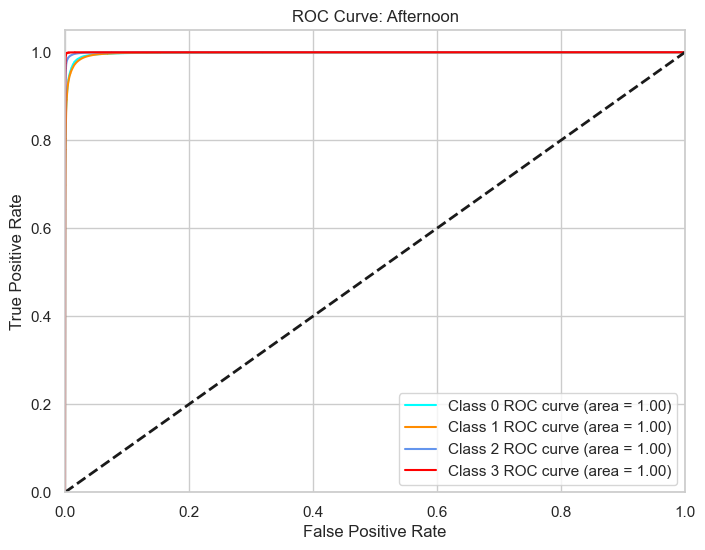


⏱️ Training model for: EVENING
              precision    recall  f1-score   support

         low      0.960     0.947     0.953    153422
      medium      0.943     0.948     0.946    202155
        high      0.985     0.989     0.987    333138
   congested      0.933     0.927     0.930      4370

    accuracy                          0.967    693085
   macro avg      0.955     0.953     0.954    693085
weighted avg      0.967     0.967     0.967    693085



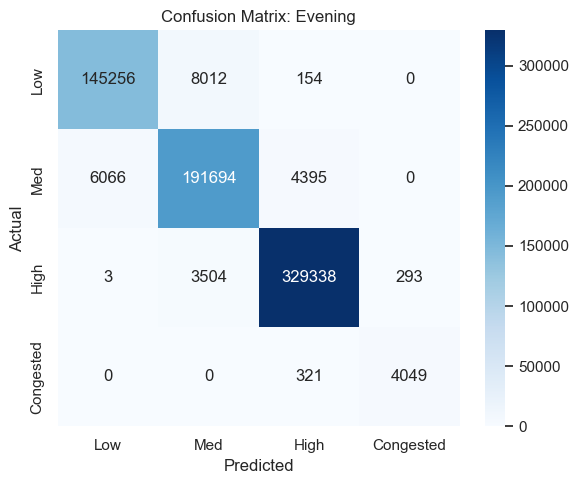

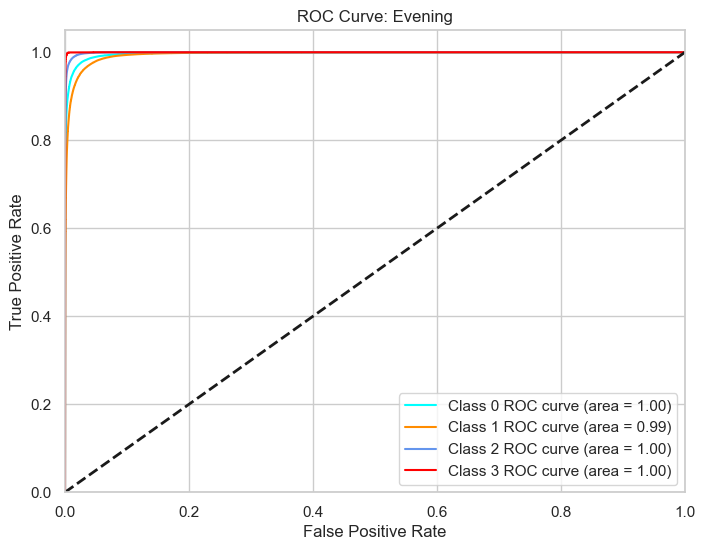


⏱️ Training model for: DAILY
              precision    recall  f1-score   support

         low      0.990     1.000     0.995     32270
      medium      0.996     0.996     0.996    210310
        high      0.997     0.997     0.997    284830
   congested      1.000     0.997     0.999    165675

    accuracy                          0.997    693085
   macro avg      0.996     0.998     0.997    693085
weighted avg      0.997     0.997     0.997    693085



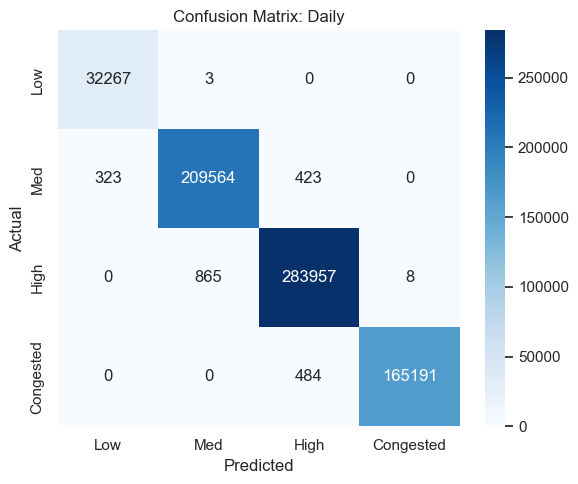

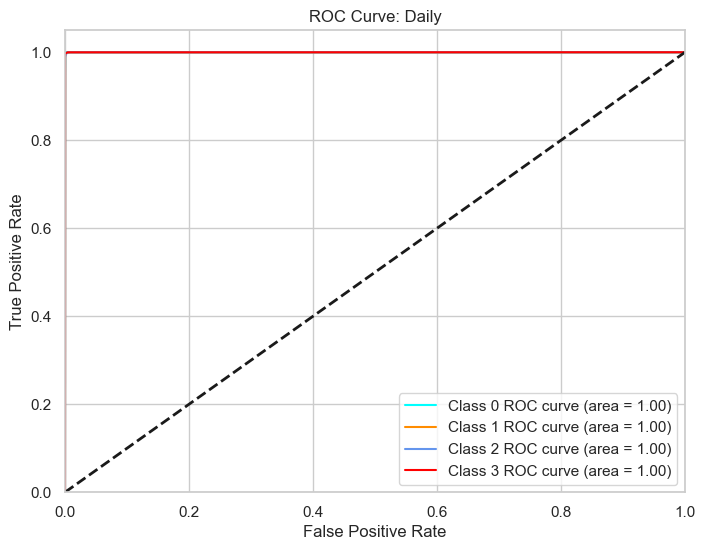

In [18]:
time_blocks = ['night', 'morning', 'afternoon', 'evening']
n_classes = 4

results = {}

for block in list(time_windows.keys()) + ['daily']:  # Include daily as a block
    print(f"\n⏱️ Training model for: {block.upper()}")

    X = df_encoded[feature_cols]
    y = df_encoded[f'{block}_label']


    if len(X) < 50:
        print(f"⚠️ Not enough valid samples for {block} — skipping.")
        continue

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, stratify=y, test_size=0.2, random_state=42
    )

    X_train['public_holiday']   = X_train['public_holiday'].astype(int)
    X_train['school_holiday']   = X_train['school_holiday'].astype(int)

    # medians = X_train.median()
    # X_train = X_train.fillna(medians)
    # X_test  = X_test.fillna(medians)

    # X_train = X_train.fillna(0)
    # X_test  = X_test.fillna(0)



    # #SMOTE on train set
    # smote = SMOTE(random_state= 42)
    # X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

    model = XGBClassifier(
        objective='multi:softprob',
        num_class=4,
        use_label_encoder=False,
        eval_metric='mlogloss',
        random_state=42
    )
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)

    print(classification_report(
        y_test, y_pred, digits=3,
        target_names=['low', 'medium', 'high', 'congested']
    ))

    cm = confusion_matrix(y_test, y_pred)
    results[block] = cm

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=['Low', 'Med', 'High', 'Congested'],
        yticklabels=['Low', 'Med', 'High', 'Congested']
    )
    plt.title(f"Confusion Matrix: {block.title()}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

    # ROC Curve plot (One-vs-Rest)
    y_test_bin = label_binarize(y_test, classes=list(range(n_classes)))
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'red'])

    plt.figure(figsize=(8, 6))
    for i, color in zip(range(n_classes), colors):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
        plt.plot(fpr[i], tpr[i], color=color,
                 label=f'Class {i} ROC curve (area = {roc_auc[i]:0.2f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f"ROC Curve: {block.title()}")
    plt.legend(loc="lower right")
    plt.show()